In [19]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print("✅ Libraries ready!")

✅ Libraries ready!


In [20]:
# Cell 2 — Upload & Load Data
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('covid_19_data.csv')
print(f"✅ Data loaded — {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Saving covid_19_data.csv to covid_19_data (1).csv
✅ Data loaded — 306429 rows, 8 columns


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [21]:
# Cell 3 — Inspect the Data
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Column Names: ['SNo', 'ObservationDate', 'Province/State', 'Country/Region', 'Last Update', 'Confirmed', 'Deaths', 'Recovered']

Data Types:
 SNo                  int64
ObservationDate     object
Province/State      object
Country/Region      object
Last Update         object
Confirmed          float64
Deaths             float64
Recovered          float64
dtype: object

Missing Values:
 SNo                    0
ObservationDate        0
Province/State     78103
Country/Region         0
Last Update            0
Confirmed              0
Deaths                 0
Recovered              0
dtype: int64


In [22]:
# Cell 4 — Fix the date column
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

print("✅ Date column fixed!")
print("Date range:", df['ObservationDate'].min(), "to", df['ObservationDate'].max())

✅ Date column fixed!
Date range: 2020-01-22 00:00:00 to 2021-05-29 00:00:00


In [23]:
# Cell 5 — Summary Statistics
df[['Confirmed', 'Deaths', 'Recovered']].describe()

,Confirmed,Deaths,Recovered
count,3.064290e+05,306429.000000,3.064290e+05
mean,8.567091e+04,2036.403268,5.042029e+04
std,2.775516e+05,6410.938048,2.015124e+05
min,-3.028440e+05,-178.000000,-8.544050e+05
25%,1.042000e+03,13.000000,1.100000e+01
50%,1.037500e+04,192.000000,1.751000e+03
75%,5.075200e+04,1322.000000,2.027000e+04
max,5.863138e+06,112385.000000,6.399531e+06


## Challenge 1 — Data Inspection Finding

The dataset spans January 2020 to May 2021 covering 306,429 records.
Confirmed cases are heavily right-skewed — a small number of countries
drove extremely high case counts, pulling the mean far above the median.
Province/State has 78,103 missing values which is expected as many
countries only report at national level.

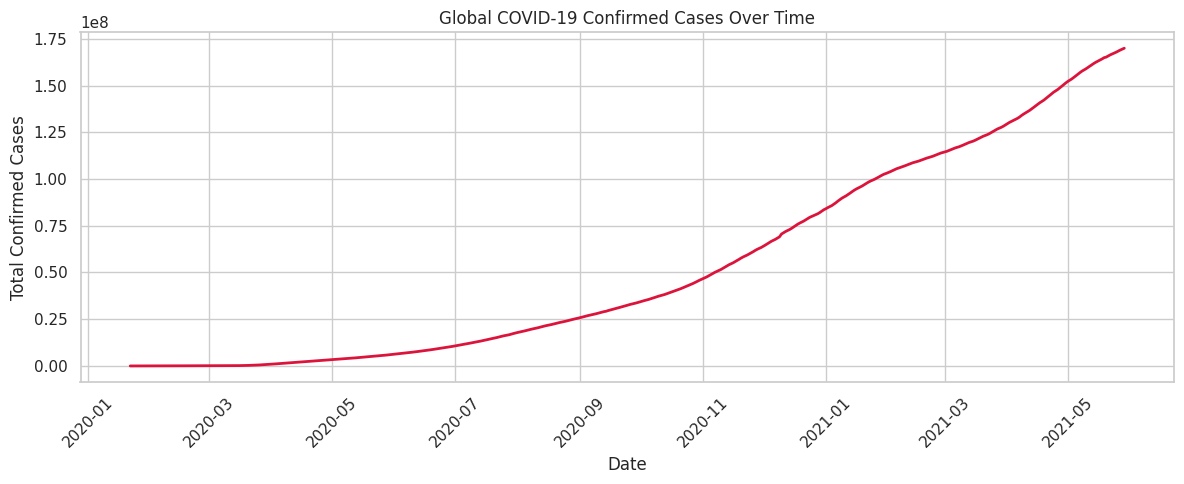

In [24]:
# Cell 6 — Global confirmed cases over time
global_by_date = df.groupby('ObservationDate')['Confirmed'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(global_by_date['ObservationDate'],
         global_by_date['Confirmed'],
         color='crimson', linewidth=2)
plt.title('Global COVID-19 Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Challenge 2 — Time Series Finding

Global COVID-19 confirmed cases followed an exponential growth pattern.
Cases remained relatively low from January to May 2020, then began
accelerating through mid-2020, with explosive growth from September 2020
onwards as the second wave hit multiple continents simultaneously.

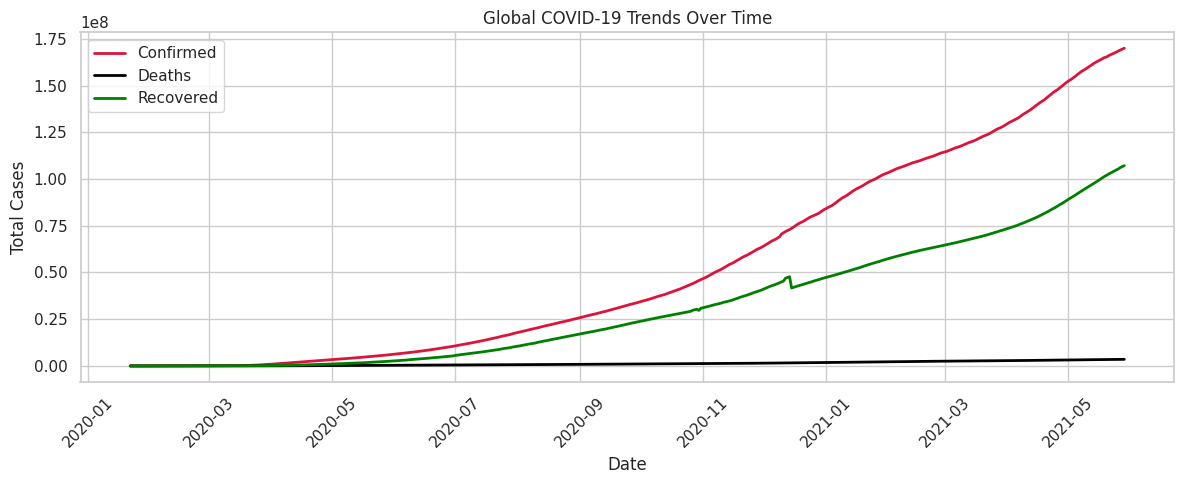

In [25]:
# Cell 7 — Confirmed, Deaths and Recovered over time
global_trends = df.groupby('ObservationDate')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(global_trends['ObservationDate'], global_trends['Confirmed'],
         color='crimson', linewidth=2, label='Confirmed')
plt.plot(global_trends['ObservationDate'], global_trends['Deaths'],
         color='black', linewidth=2, label='Deaths')
plt.plot(global_trends['ObservationDate'], global_trends['Recovered'],
         color='green', linewidth=2, label='Recovered')
plt.title('Global COVID-19 Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Challenge 2 — Three Trends Finding

All three metrics — Confirmed, Deaths and Recovered — increased
consistently over time showing a positive correlation. Deaths remained
proportionally low relative to confirmed cases, while recoveries grew
significantly from mid-2020, suggesting improving treatment outcomes
as the pandemic progressed.

In [26]:
# Cell 8 — Top 10 countries by confirmed cases
latest_date = df['ObservationDate'].max()
latest_df = df[df['ObservationDate'] == latest_date]

country_totals = latest_df.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered']].sum()
top10 = country_totals.sort_values('Confirmed', ascending=False).head(10)

print(top10)

                 Confirmed    Deaths   Recovered
Country/Region                                  
US              33251939.0  594306.0         0.0
India           27894800.0  325972.0  25454320.0
Brazil          16471600.0  461057.0  14496224.0
France           5719877.0  109518.0    390878.0
Turkey           5235978.0   47271.0   5094279.0
Russia           4995613.0  118781.0   4616422.0
UK               4496823.0  128037.0     15481.0
Italy            4213055.0  126002.0   3845087.0
Argentina        3732263.0   77108.0   3288467.0
Germany          3684672.0   88413.0   3479700.0


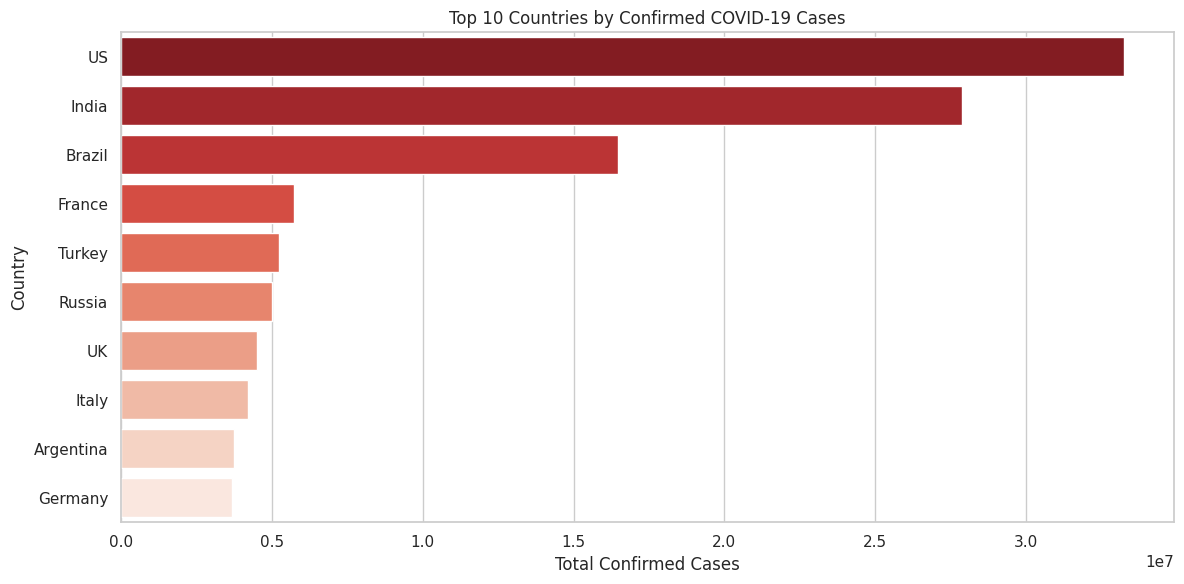

In [27]:
# Cell 9 — Top 10 countries chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top10.reset_index(),
            x='Confirmed', y='Country/Region',
            hue='Country/Region', palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Total Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Challenge 3 — Country Level Finding

The USA, India and Brazil accounted for a disproportionately large
share of global confirmed cases, significantly outpacing the remaining
top 10 countries. China, despite being the origin of the outbreak,
does not appear in the top 10 — likely reflecting early containment
measures and differing reporting methodologies. No African country
appears in the top 10, possibly due to lower testing capacity and
younger population demographics.

In [28]:
# Cell 10 — Death rate by country
latest_df2 = latest_df.groupby('Country/Region')[['Confirmed', 'Deaths']].sum().reset_index()

latest_df2['Death_Rate'] = (latest_df2['Deaths'] / latest_df2['Confirmed']) * 100

top10_death_rate = latest_df2.sort_values('Death_Rate', ascending=False).head(10)
print(top10_death_rate[['Country/Region', 'Confirmed', 'Deaths', 'Death_Rate']].round(2))

     Country/Region  Confirmed    Deaths  Death_Rate
188         Vanuatu        4.0       1.0       25.00
104      MS Zaandam        9.0       2.0       22.22
192           Yemen     6731.0    1319.0       19.60
116          Mexico  2411503.0  223455.0        9.27
167           Sudan    35289.0    2600.0        7.37
171           Syria    24440.0    1763.0        7.21
51            Egypt   260659.0   15001.0        5.76
161         Somalia    14653.0     768.0        5.24
107  Mainland China    91072.0    4636.0        5.09
50          Ecuador   424741.0   20485.0        4.82


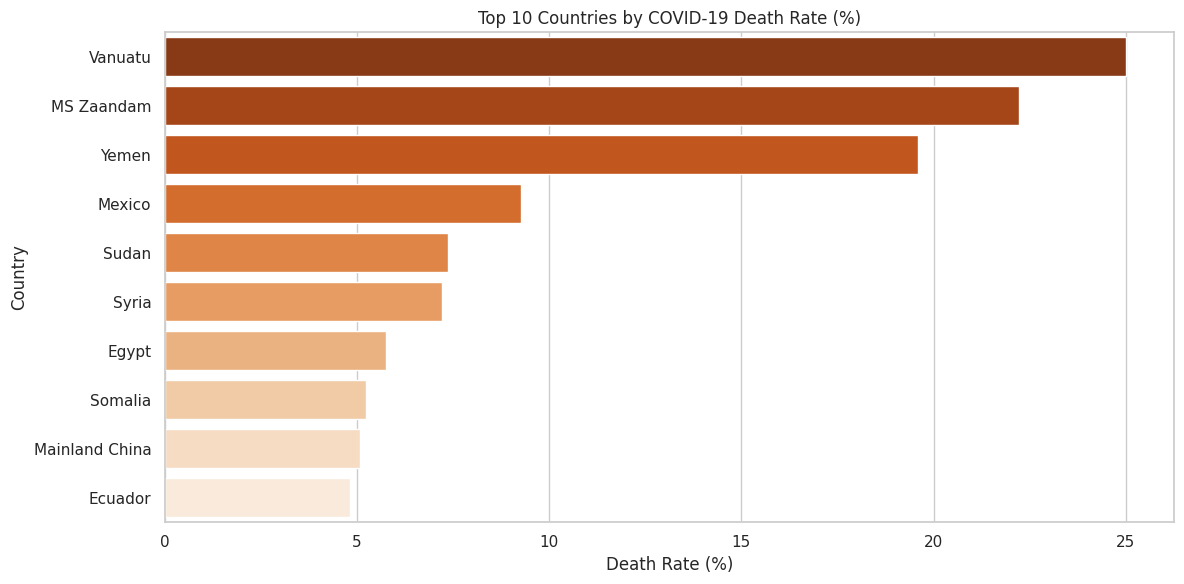

In [29]:
# Cell 11 — Top 10 death rate chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_death_rate,
            x='Death_Rate', y='Country/Region',
            hue='Country/Region', palette='Oranges_r', legend=False)
plt.title('Top 10 Countries by COVID-19 Death Rate (%)')
plt.xlabel('Death Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Challenge 4 — Death Rate Finding

The countries with the highest death rates were predominantly small
nations and African countries with limited testing infrastructure.
Vanuatu topped the list despite having very few total confirmed cases.
This reveals a critical data insight — high confirmed cases does not
equal high death rate. Countries with limited testing only captured
the most severe cases, artificially inflating their death rate percentage.
This highlights how data quality and healthcare infrastructure
significantly affect what the numbers actually show.

In [30]:
# Cell 12 — Define African countries
african_countries = [
    'South Africa', 'Morocco', 'Tunisia', 'Egypt', 'Ethiopia',
    'Nigeria', 'Kenya', 'Ghana', 'Algeria', 'Sudan', 'Libya',
    'Cameroon', 'Senegal', 'Zambia', 'Zimbabwe', 'Uganda',
    'Mozambique', 'Madagascar', 'Ivory Coast', 'Angola'
]

africa_df = df[df['Country/Region'].isin(african_countries)]

print(f"✅ African dataset — {africa_df.shape[0]} rows")
print(f"Countries included: {africa_df['Country/Region'].nunique()}")

✅ African dataset — 8913 rows
Countries included: 20


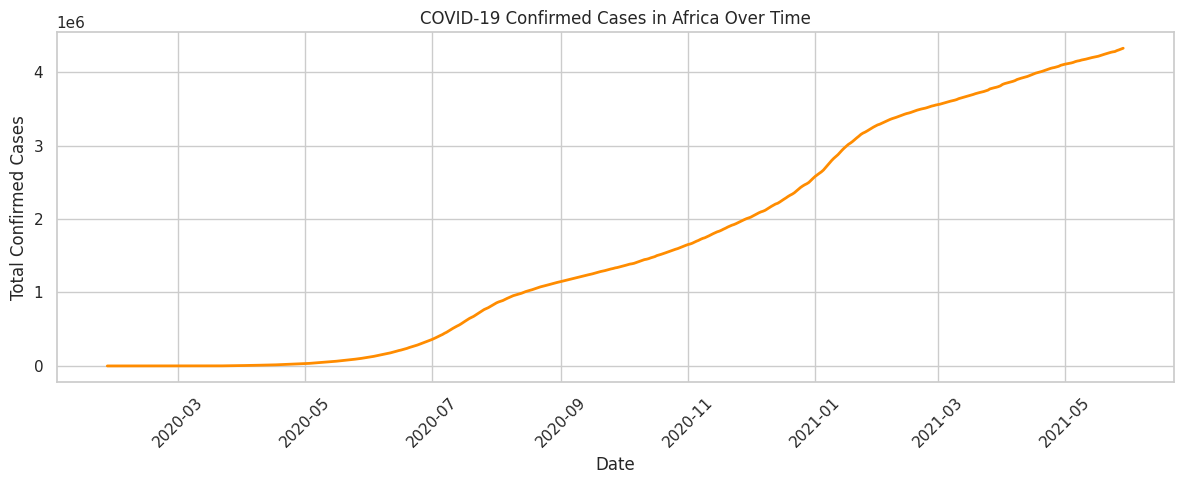

In [31]:
# Cell 13 — Africa confirmed cases over time
africa_trend = africa_df.groupby('ObservationDate')['Confirmed'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(africa_trend['ObservationDate'],
         africa_trend['Confirmed'],
         color='darkorange', linewidth=2)
plt.title('COVID-19 Confirmed Cases in Africa Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

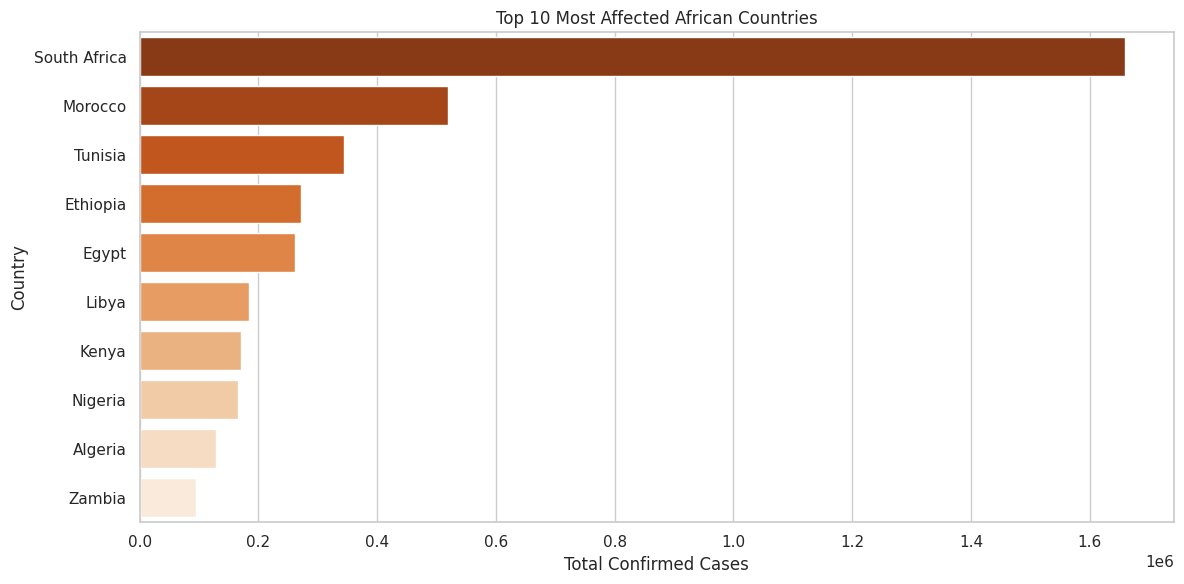

In [32]:
# Cell 14 — Top African countries by confirmed cases
africa_latest = africa_df[africa_df['ObservationDate'] == latest_date]
africa_totals = africa_latest.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered']].sum()
africa_top10 = africa_totals.sort_values('Confirmed', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=africa_top10.reset_index(),
            x='Confirmed', y='Country/Region',
            hue='Country/Region', palette='Oranges_r', legend=False)
plt.title('Top 10 Most Affected African Countries')
plt.xlabel('Total Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

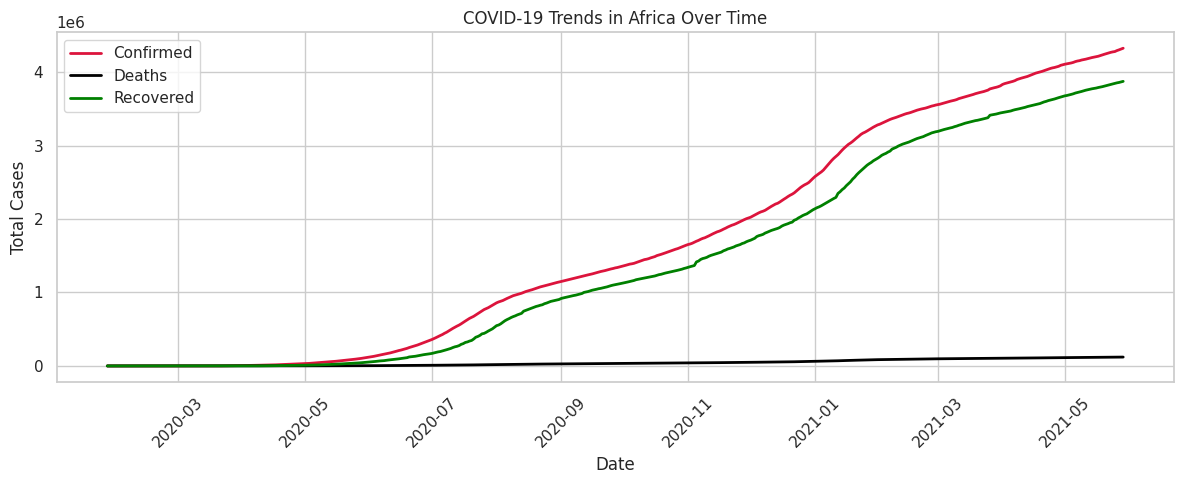

In [33]:
# Cell 15 — Africa confirmed, deaths and recovered over time
africa_trends = africa_df.groupby('ObservationDate')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(africa_trends['ObservationDate'], africa_trends['Confirmed'],
         color='crimson', linewidth=2, label='Confirmed')
plt.plot(africa_trends['ObservationDate'], africa_trends['Deaths'],
         color='black', linewidth=2, label='Deaths')
plt.plot(africa_trends['ObservationDate'], africa_trends['Recovered'],
         color='green', linewidth=2, label='Recovered')
plt.title("COVID-19 Trends in Africa Over Time")
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Challenge 5 — Africa Regional Story

Africa's COVID-19 trajectory mirrored global trends but with a delayed
explosion and slower overall growth, consistent with limited testing
capacity across the continent. South Africa dominated confirmed cases
due to superior testing infrastructure — not necessarily because it
was hit harder than other nations. Deaths remained proportionally lower
than expected, likely reflecting Africa's younger population demographics.
Nigeria appeared in the top 10 most affected African countries, reflecting
both its large population and relatively stronger reporting capacity
compared to other African nations.

## Key Insights — COVID-19 Data Analysis

1. EXPONENTIAL GROWTH
   Global confirmed cases followed an exponential growth pattern,
   starting slowly in early 2020 before exploding from September 2020
   as the second wave hit multiple continents simultaneously.

2. THE BIG THREE
   USA, India and Brazil accounted for a disproportionately large share
   of global confirmed cases, significantly outpacing all other countries.

3. CONFIRMED CASES ≠ DEATH RATE
   The countries with the most confirmed cases were NOT the deadliest.
   Smaller nations with limited testing had the highest death rates
   because only the most severe cases were ever confirmed.

4. AFRICA'S STORY
   South Africa dominated Africa's confirmed cases due to superior
   testing infrastructure. Africa's younger population likely contributed
   to proportionally lower death numbers despite healthcare limitations.

5. DATA QUALITY MATTERS
   Throughout this analysis the most important lesson was that numbers
   without context are misleading. Testing capacity, reporting
   infrastructure and population demographics all shape what the
   data shows — and what it hides.